# **Implementación de los casos de 3 Qubits**

In [26]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
seed = 42

In [28]:
N3 = 1961

In [29]:
threeQubit = SchnorrAlgQAOA(N3, 1.5, 1, seed)

El numero de bits de N = 1961 es m = 11
La dimension del reticulo que vamos a tratar es n = 3
La cota smooth que vamos a tomar: 9


In [30]:
B3, t3 = threeQubit.generate_cvp(10)
print(f'B3 = \n{B3}')
print(f't3 = \n{t3}')

B3 = 
[ 1 0 0 22 ]
[ 0 1 0 35 ]
[ 0 0 2 51 ]
t3 = 
(0, 0, 0, 240)


In [31]:
D3 = threeQubit.lll_reduced(B3, delta = 0.75)
print(f'D3 = \n{D3}')

D3 = 
[  1 -2 2  3 ]
[ -4  1 2 -2 ]
[ -3  2 0  4 ]


In [32]:
D3, b3_op, res3_vector, sign_step3, w3, dist3 = threeQubit.babai_algorithm(B3, t3, delta = 0.75)
print(f'D3 = \n{D3}\n')
print(f'b3_op = \n{b3_op}\n')
print(f'res3_vector = \n{res3_vector}\n')
print(f'sign_step3 = \n{sign_step3}\n')
print(f'w3 = \n{w3}\n')
print(f'dist3 = \n{dist3}\n')

D3 = 
[  1 -2 2  3 ]
[ -4  1 2 -2 ]
[ -3  2 0  4 ]

b3_op = 
[  0   4   4 242]

res3_vector = 
[ 0 -4 -4 -2]

sign_step3 = 
[-1 -1 -1]

w3 = 
(22, -20, 34)

dist3 = 
6.0



In [33]:
qubo3 = threeQubit.define_qubo(D3, res3_vector, sign_step3)

print(qubo3.prettyprint())

Problem name: quboProblem

Minimize
  18*z_0^2 - 16*z_0*z_1 + 10*z_0*z_2 + 25*z_1^2 + 12*z_1*z_2 + 29*z_2^2 - 12*z_0
  - 16*z_1 - 32*z_2 + 36

Subject to
  No constraints

  Binary variables (3)
    z_0 z_1 z_2



In [34]:
Hc3, offset3 = threeQubit.define_hamiltonian(qubo3)

print("Offset = {}\n".format(offset3))
print("Hamiltonian = {}".format(Hc3))

Offset = 43.5

Hamiltonian = SparsePauliOp(['IZI', 'ZII', 'IIZ', 'IZZ', 'ZIZ', 'ZZI'],
              coeffs=[-3.5+0.j, -4. +0.j, -1.5+0.j, -4. +0.j,  2.5+0.j,  3. +0.j])


In [35]:
formatted_h = " + ".join([f"{c.real:.3f}{s}" for s, c in Hc3.label_iter()])
print(formatted_h)

-3.500IZI + -4.000ZII + -1.500IIZ + -4.000IZZ + 2.500ZIZ + 3.000ZZI


In [36]:
circuit3 = threeQubit.construct_circuit(Hc3, 2)
print(circuit3.decompose(reps = 2))

     ┌────────────┐┌───────────────┐                             ┌────────────┐»
q_0: ┤ U(π/2,0,π) ├┤ Rz((-3)*γ[0]) ├─■───────────────■───────────┤ Rx(2*β[0]) ├»
     ├────────────┤├───────────────┤ │ZZ((-8)*γ[0])  │           └────────────┘»
q_1: ┤ U(π/2,0,π) ├┤ Rz((-7)*γ[0]) ├─■───────────────┼────────────■────────────»
     ├────────────┤├───────────────┤                 │ZZ(5*γ[0])  │ZZ(6*γ[0])  »
q_2: ┤ U(π/2,0,π) ├┤ Rz((-8)*γ[0]) ├─────────────────■────────────■────────────»
     └────────────┘└───────────────┘                                           »
«     ┌───────────────┐                                              »
«q_0: ┤ Rz((-3)*γ[1]) ├──────────────────■───────────────■───────────»
«     └─┬────────────┬┘┌───────────────┐ │ZZ((-8)*γ[1])  │           »
«q_1: ──┤ Rx(2*β[0]) ├─┤ Rz((-7)*γ[1]) ├─■───────────────┼───────────»
«       ├────────────┤ ├───────────────┤                 │ZZ(5*γ[1]) »
«q_2: ──┤ Rx(2*β[0]) ├─┤ Rz((-8)*γ[1]) ├─────────────────■───────────»
«      

In [37]:
x0 = np.asarray([0.0]*circuit3.num_parameters)

optParameters3 = threeQubit.qaoa_algorithm(circuit3, Hc3, x0)

In [38]:
print(optParameters3)

{ParameterVectorElement(β[0]): np.float64(0.30328493417438884), ParameterVectorElement(β[1]): np.float64(0.30222238730602863), ParameterVectorElement(γ[0]): np.float64(-0.05486743268952691), ParameterVectorElement(γ[1]): np.float64(-0.06905953362590297)}


In [39]:
ncircuit3 = threeQubit.circ_asign_params(circuit3, optParameters3)
print(ncircuit3.decompose(reps=2))

     ┌────────────┐ ┌────────────┐                             ┌─────────────┐»
q_0: ┤ U(π/2,0,π) ├─┤ Rz(0.1646) ├─■─────────────■─────────────┤ Rx(0.60657) ├»
     ├────────────┤┌┴────────────┤ │ZZ(0.43894)  │             └─────────────┘»
q_1: ┤ U(π/2,0,π) ├┤ Rz(0.38407) ├─■─────────────┼───────────────■────────────»
     ├────────────┤├─────────────┤               │ZZ(-0.27434)   │ZZ(-0.3292) »
q_2: ┤ U(π/2,0,π) ├┤ Rz(0.43894) ├───────────────■───────────────■────────────»
     └────────────┘└─────────────┘                                            »
«     ┌─────────────┐                                           ┌─────────────┐»
«q_0: ┤ Rz(0.20718) ├────────────────■─────────────■────────────┤ Rx(0.60444) ├»
«     ├─────────────┤┌─────────────┐ │ZZ(0.55248)  │            └─────────────┘»
«q_1: ┤ Rx(0.60657) ├┤ Rz(0.48342) ├─■─────────────┼─────────────■─────────────»
«     ├─────────────┤├─────────────┤               │ZZ(-0.3453)  │ZZ(-0.41436) »
«q_2: ┤ Rx(0.60657) ├┤ Rz(0.55248) 

In [40]:
results3 = threeQubit.sample_from_parameters(circuit3, optParameters3, shots = 10_000)
print(len(results3))
for bitstring, count in results3.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

8
Bistring: 011 -> Counts: 3123
Bistring: 100 -> Counts: 2881
Bistring: 000 -> Counts: 2739
Bistring: 001 -> Counts: 935
Bistring: 010 -> Counts: 220
Bistring: 110 -> Counts: 47
Bistring: 111 -> Counts: 36
Bistring: 101 -> Counts: 19


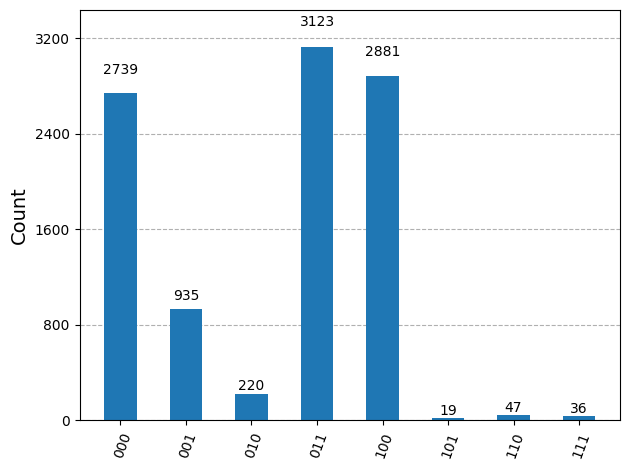

In [41]:
plot_histogram(results3)

In [42]:
nD3 = threeQubit.integer_to_matrix(D3)
print(nD3)

[[ 1 -2  2  3]
 [-4  1  2 -2]
 [-3  2  0  4]]


In [43]:
vnew3 = threeQubit.bitstring2latticeVectors(nD3, results3.keys(), sign_step3, b3_op)
print(vnew3)

[[  3   5   0 241]
 [  3   2   4 238]
 [  0   4   4 242]
 [ -1   6   2 239]
 [  4   3   2 244]
 [  7   1   2 240]
 [  6   3   0 237]
 [  2   4   2 235]]


In [44]:
distances3 = threeQubit.get_distances(vnew3, t3)
for dist in distances3:
    print(np.linalg.norm(dist))

5.916079783099616
5.744562646538029
6.0
6.48074069840786
6.708203932499369
7.3484692283495345
7.3484692283495345
7.0


In [45]:
nB3 = threeQubit.integer_to_matrix(B3)
print(nB3)

[[ 1  0  0 22]
 [ 0  1  0 35]
 [ 0  0  2 51]]


In [46]:
uv_pairs3 = threeQubit.vectors2uv_pairs(nB3, vnew3)
print(uv_pairs3)

[[1944 1]
 [1800 1]
 [2025 1]
 [3645 2]
 [2160 1]
 [1920 1]
 [1728 1]
 [1620 1]]


In [47]:
sr_pairs3 = threeQubit.uv_pairs2sr_pairs(uv_pairs3)
print(sr_pairs3)

[(1944, 1), (1800, 1), (2025, 1)]


In [48]:
probs3 = threeQubit.get_probs(results3.values(), shots = 10_000)

In [50]:
threeQubit.prettyprint(vnew3, distances3, probs3, b3_op, t3, res3_vector, dist3)

Vector más corto por algoritmo de Babai: 
b_op = [  0   4   4 242]

El vector residual 
t - b_op = [ 0 -4 -4 -2]

La distancia |t - b_op| = 6.000

0: Prob = 0.31230
	vnew = [  3   5   0 241] con distancia: 5.916
1: Prob = 0.28810
	vnew = [  3   2   4 238] con distancia: 5.745
2: Prob = 0.27390
	vnew = [  0   4   4 242] con distancia: 6.000
3: Prob = 0.09350
	vnew = [ -1   6   2 239] con distancia: 6.481
4: Prob = 0.02200
	vnew = [  4   3   2 244] con distancia: 6.708
5: Prob = 0.00470
	vnew = [  7   1   2 240] con distancia: 7.348
6: Prob = 0.00360
	vnew = [  6   3   0 237] con distancia: 7.348
7: Prob = 0.00190
	vnew = [  2   4   2 235] con distancia: 7.000


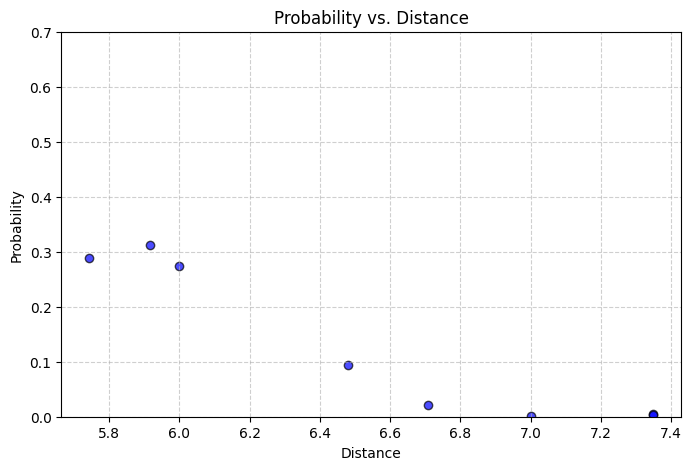

In [49]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances3, probs3, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.70) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()